# Experiment 1: EKF + SoC Estimation

### Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import os
import glob

### Load dataset

In [5]:
# Root directory
ROOT = "./datasets/1_NCA"

csv_files = glob.glob(os.path.join(ROOT, "*.csv"))
dataframes = []
for file in csv_files:
    df = pd.read_csv(file)
    dataframes.append(df)

print(f"Total files read: {len(dataframes)}")

Total files read: 66


In [6]:
df1 = pd.read_csv("datasets/1_NCA/CY25-1_1-#1.csv")
df1.head(10)

,time/s,control/V/mA,Ecell/V,<I>/mA,Q discharge/mA.h,Q charge/mA.h,control/V,control/mA,cycle number
0,0.000,3500.0,3.149101,0.058311,0.0,0.001944,0.0,3500,2
1,0.014,3500.0,3.154381,3499.796569,0.0,0.015554,0.0,3500,2
2,0.070,3500.0,3.159463,3500.127389,0.0,0.070001,0.0,3500,2
3,0.202,3500.0,3.164467,3500.217622,0.0,0.198342,0.0,3500,2
4,0.412,3500.0,3.169628,3500.402831,0.0,0.402532,0.0,3500,2
5,0.682,3500.0,3.174632,3500.313356,0.0,0.665056,0.0,3500,2
6,0.988,3500.0,3.179675,3500.408428,0.0,0.962590,0.0,3500,2
7,1.342,3500.0,3.184758,3500.325451,0.0,1.306789,0.0,3500,2
8,1.732,3500.0,3.189801,3500.398931,0.0,1.685999,0.0,3500,2
9,2.148,3500.0,3.194844,3500.469302,0.0,2.090498,0.0,3500,2


In [8]:
df1 = df1.sort_values(["cycle number", "time/s"]).reset_index(drop=True)

# Convert column names for aliases
df1 = df1.rename(columns={
    "time/s": "time",
    "Ecell/V": "voltage",
    "<I>/mA": "current",
    "Q discharge/mA.h": "Q_dis",
    "Q charge/mA.h": "Q_chg",
    "cycle number": "cycle"
})

cycles = sorted(df1["cycle"].unique())
print(f"Total cycles: {len(cycles)} | Cycle range: {cycles[0]} — {cycles[-1]}")

Total cycles: 35 | Cycle range: 2 — 36


In [10]:
# STEP 1 — Determine nominal capacity (Q_nom): Use the maximum charge capacity from the first few healthy cycles
early_cycles = cycles[:5]
Q_nom = df1[df1["cycle"].isin(early_cycles)].groupby("cycle")["Q_chg"].max().mean()
print(f"Nominal capacity (Q_nom): {Q_nom:.2f} mA.h")

Nominal capacity (Q_nom): 3167.07 mA.h


In [13]:
# STEP 2 — Coulomb Counting SoC per cycle SoC(t) = (Q_chg(t) - Q_dis(t)) / Q_nom. Clipped to [0, 1] to handle noise.
df1["SoC_cc"] = ((df1["Q_chg"] - df1["Q_dis"]) / Q_nom).clip(0, 1)

In [14]:
# STEP 3 — Extract OCV–SoC curve from rest periods. Rest = rows where |current| is very small. At rest, measured voltage ≈ Open Circuit Voltage (OCV)
REST_THRESHOLD_MA = 50  # adjust based on your sensor noise floor

rest_df = df1[np.abs(df1["current"]) < REST_THRESHOLD_MA].copy()
rest_df = rest_df.dropna(subset=["voltage", "SoC_cc"])
rest_df = rest_df[rest_df["SoC_cc"].between(0.01, 0.99)]  # exclude edge saturation

# Sort and remove duplicates for interpolation
rest_df_sorted = rest_df.sort_values("SoC_cc").drop_duplicates(subset="SoC_cc")

print(f"Rest-period samples for OCV curve: {len(rest_df_sorted)}")

Rest-period samples for OCV curve: 27


In [15]:
# Fit a smooth OCV–SoC lookup using 1D interpolation, using this as the EKF measurement model: OCV = f(SoC)
if len(rest_df_sorted) >= 10:
    ocv_soc_interp = interp1d(
        rest_df_sorted["SoC_cc"].values,
        rest_df_sorted["voltage"].values,
        kind="linear",
        bounds_error=False,
        fill_value=(rest_df_sorted["voltage"].iloc[0], rest_df_sorted["voltage"].iloc[-1])
    )
    print("OCV–SoC interpolation built successfully.")
else:
    # Fallback: use a simple linear model if not enough rest points
    p = np.polyfit(rest_df_sorted["SoC_cc"].values, rest_df_sorted["voltage"].values, 3)
    ocv_soc_interp = np.poly1d(p)
    print("Warning: Few rest points — using polynomial fallback for OCV curve.")

OCV–SoC interpolation built successfully.


In [16]:
# STEP 4 — Estimate internal resistance R0. R0 = ΔV / ΔI at current step events, (voltage drop when current suddenly changes)
df1["dI"] = df1.groupby("cycle")["current"].diff()
df1["dV"] = df1.groupby("cycle")["voltage"].diff()

# Only consider large, sudden current steps (pulse events)
step_mask = np.abs(df1["dI"]) > 500  # mA threshold for step detection
step_events = df1[step_mask].copy()
step_events["R0_est"] = np.abs(step_events["dV"] / (step_events["dI"] / 1000))  # resistance

# Filter out physically unreasonable values
step_events = step_events[(step_events["R0_est"] > 0.001) & (step_events["R0_est"] < 1.0)]

R0 = step_events["R0_est"].median() if len(step_events) > 0 else 0.05  # fallback 50mΩ
print(f"Estimated R0 (internal resistance): {R0*1000:.2f} mΩ")

Estimated R0 (internal resistance): 1.45 mΩ


STEP 5 — Extended Kalman Filter (EKF) for SoC
- State:       x = SoC  (scalar)
- Process:     x_k = x_{k-1} + (η * I * Δt) / Q_nom
- Measurement: z_k = OCV(x_k) + R0 * I_k   ← terminal voltage model
- Noise:       Q_proc = process noise (current sensor error)
- R_meas = measurement noise (voltage sensor error)

In [17]:
def ekf_soc(time_arr, current_arr, voltage_arr, ocv_fn, Q_nom_mah, R0_ohm,
            Q_proc=1e-5, R_meas=1e-3, soc_init=0.5):
    """
    Scalar EKF for SoC estimation.

    Parameters
    ----------
    time_arr    : array of timestamps (seconds)
    current_arr : array of current values (mA), positive = charging
    voltage_arr : array of terminal voltage (V)
    ocv_fn      : callable, OCV = f(SoC)
    Q_nom_mah   : nominal capacity in mA.h
    R0_ohm      : internal resistance in Ohms
    Q_proc      : process noise variance (tune this)
    R_meas      : measurement noise variance (tune this)
    soc_init    : initial SoC guess [0, 1]

    Returns
    -------
    soc_ekf : array of EKF-corrected SoC values
    """
    Q_nom_as = Q_nom_mah * 3.6          # convert mA.h → mA.s (= mC)
    n = len(time_arr)
    soc_ekf = np.zeros(n)

    x = soc_init        # initial state
    P = 0.1             # initial error covariance (uncertainty in SoC)

    for k in range(n):
        # Time step
        if k == 0:
            dt = 0.0
        else:
            dt = time_arr[k] - time_arr[k - 1]
            dt = max(dt, 0)             # guard against non-monotonic time

        I_k = current_arr[k]           # current in mA
        V_k = voltage_arr[k]           # measured terminal voltage

        # Predict step
        eta = 1.0                       # coulombic efficiency (1.0 = ideal)
        x_pred = x + (eta * I_k * dt) / Q_nom_as
        x_pred = np.clip(x_pred, 0.0, 1.0)
        P_pred = P + Q_proc

        # Measurement model: V_terminal = OCV(SoC) + R0 * I
        OCV_pred = float(ocv_fn(x_pred))
        V_pred = OCV_pred + R0_ohm * (I_k / 1000.0)   # I in Amps for voltage calc

        # Jacobian of measurement model w.r.t. SoC
        # H = dOCV/dSoC - approximate numerically
        delta = 1e-4
        H = (float(ocv_fn(np.clip(x_pred + delta, 0, 1))) -
             float(ocv_fn(np.clip(x_pred - delta, 0, 1)))) / (2 * delta)

        # Kalman gain
        S = H * P_pred * H + R_meas    # innovation covariance
        K = P_pred * H / S             # Kalman gain

        # Update step
        innovation = V_k - V_pred
        x = x_pred + K * innovation
        x = np.clip(x, 0.0, 1.0)
        P = (1 - K * H) * P_pred

        soc_ekf[k] = x

    return soc_ekf

In [20]:
# STEP 6 — Run EKF on each cycle
soc_ekf_all = []

for cycle_id in cycles:
    sub = df1[df1["cycle"] == cycle_id].copy().reset_index(drop=True)

    # Initial SoC guess: use Coulomb Counting value at start of cycle
    soc_init_guess = sub["SoC_cc"].iloc[0]

    soc_ekf_cycle = ekf_soc(
        time_arr=sub["time"].values,
        current_arr=sub["current"].values,
        voltage_arr=sub["voltage"].values,
        ocv_fn=ocv_soc_interp,
        Q_nom_mah=Q_nom,
        R0_ohm=R0,
        Q_proc=1e-5,       # tune: increase if CC drifts fast
        R_meas=1e-3,       # tune: increase if voltage is noisy
        soc_init=soc_init_guess
    )

    soc_ekf_all.extend(soc_ekf_cycle)

df1["SoC_ekf"] = soc_ekf_all

In [21]:
# STEP 7 — State of Health (SoH) per cycle
#    SoH = actual capacity / nominal capacity
#    Use max Q_chg per cycle as actual capacity

cycle_cap = df1.groupby("cycle")["Q_chg"].max().reset_index()
cycle_cap.columns = ["cycle", "Q_actual"]
cycle_cap["SoH"] = (cycle_cap["Q_actual"] / Q_nom * 100).clip(0, 100)

print("\nSoH per cycle (first 10):")
print(cycle_cap.head(10).to_string(index=False))

# Merge SoH back into main df for reference
df1 = df1.merge(cycle_cap[["cycle", "SoH"]], on="cycle", how="left")


SoH per cycle (first 10):
 cycle    Q_actual        SoH
     2 3167.135066 100.000000
     3 3166.161775  99.971433
     4 3169.993505 100.000000
     5 3168.332858 100.000000
     6 3163.709340  99.893998
     7 3157.262669  99.690444
     8 3151.621111  99.512312
     9 3143.084993  99.242785
    10 3132.028947  98.893690
    11 3120.832821  98.540173


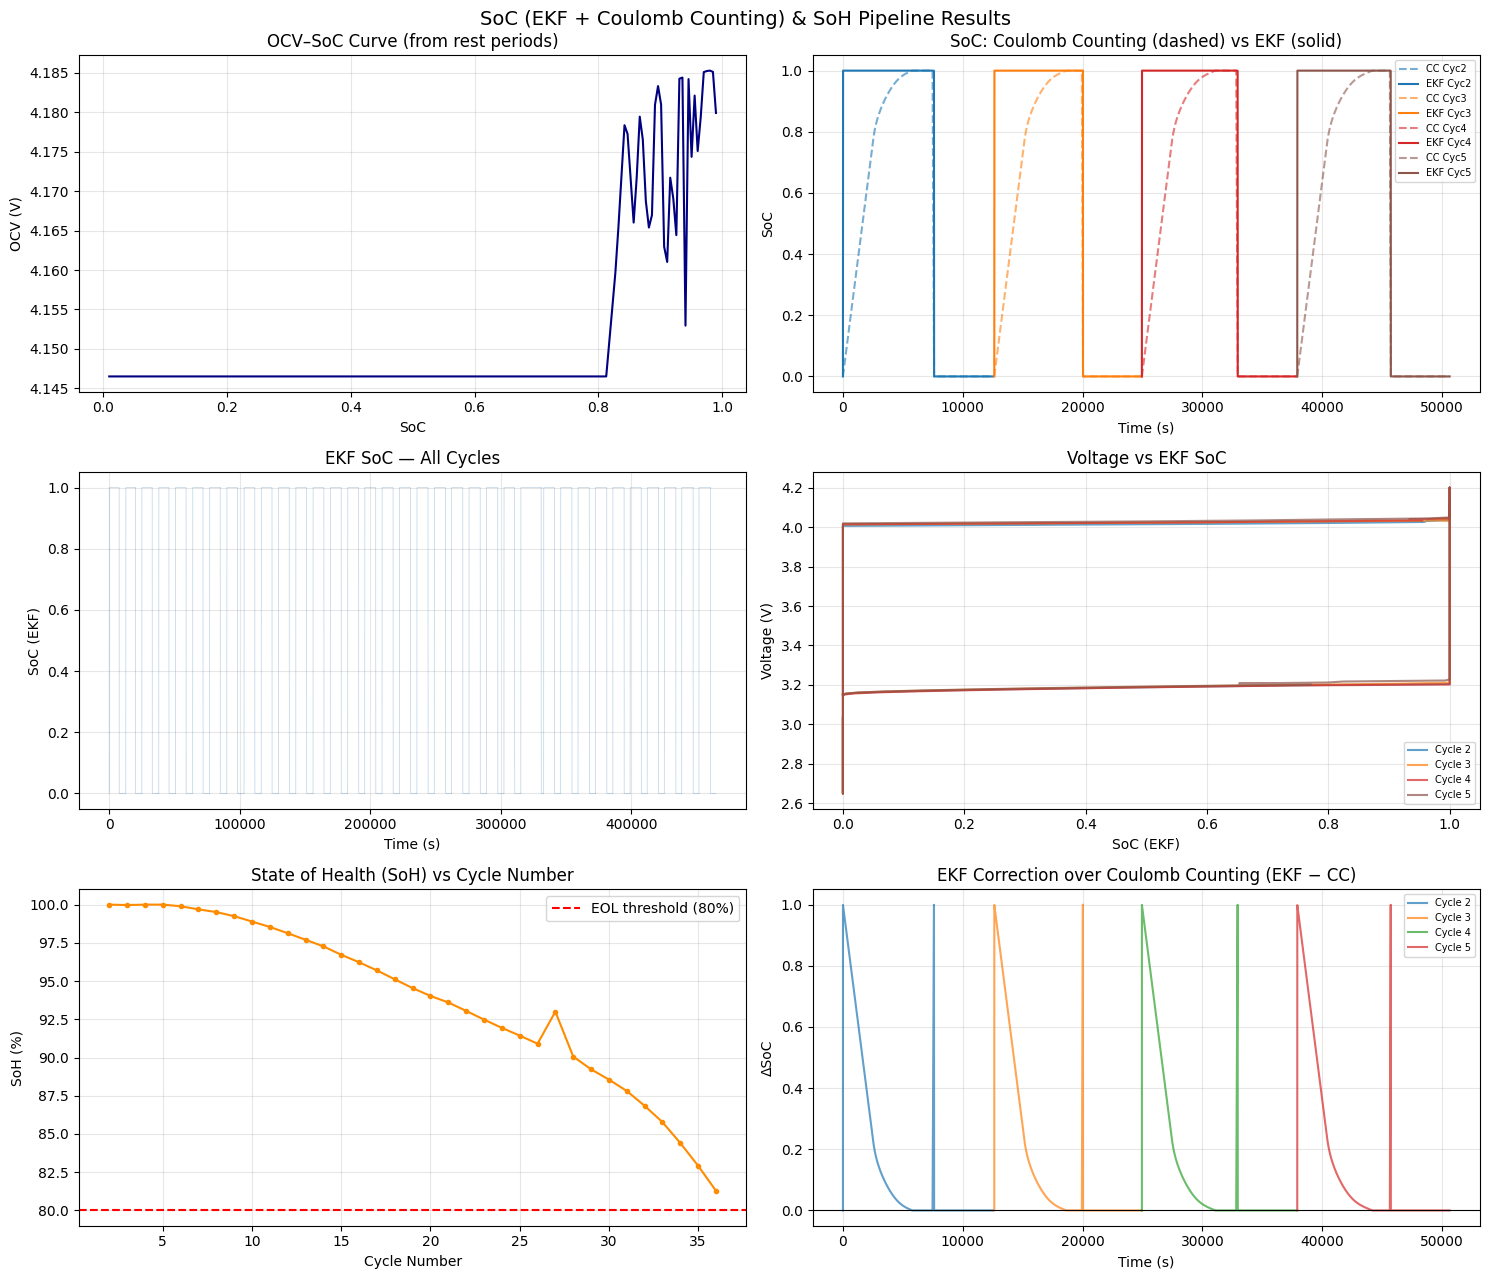

In [23]:
# STEP 8 — Visualize results
fig, axes = plt.subplots(3, 2, figsize=(15, 13))
fig.suptitle("SoC (EKF + Coulomb Counting) & SoH Pipeline Results", fontsize=14)

# Plot 1: OCV–SoC curve
soc_range = np.linspace(0.01, 0.99, 200)
ocv_vals = [float(ocv_soc_interp(s)) for s in soc_range]
axes[0, 0].plot(soc_range, ocv_vals, color="navy")
axes[0, 0].set_title("OCV–SoC Curve (from rest periods)")
axes[0, 0].set_xlabel("SoC")
axes[0, 0].set_ylabel("OCV (V)")
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: SoC_CC vs SoC_EKF for a few cycles
plot_cycles = cycles[:4]
colors = plt.cm.tab10(np.linspace(0, 0.5, len(plot_cycles)))

for i, cid in enumerate(plot_cycles):
    sub = df1[df1["cycle"] == cid]
    axes[0, 1].plot(sub["time"], sub["SoC_cc"], linestyle="--", color=colors[i], alpha=0.6, label=f"CC Cyc{cid}")
    axes[0, 1].plot(sub["time"], sub["SoC_ekf"], linestyle="-", color=colors[i], label=f"EKF Cyc{cid}")

axes[0, 1].set_title("SoC: Coulomb Counting (dashed) vs EKF (solid)")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("SoC")
axes[0, 1].legend(fontsize=7)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: EKF SoC for all cycles
for cid in cycles:
    sub = df1[df1["cycle"] == cid]
    axes[1, 0].plot(sub["time"], sub["SoC_ekf"], alpha=0.3, linewidth=0.6, color="steelblue")

axes[1, 0].set_title("EKF SoC — All Cycles")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("SoC (EKF)")
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Voltage vs EKF SoC
for i, cid in enumerate(plot_cycles):
    sub = df1[df1["cycle"] == cid]
    axes[1, 1].plot(sub["SoC_ekf"], sub["voltage"], color=colors[i], alpha=0.7, label=f"Cycle {cid}")

axes[1, 1].set_title("Voltage vs EKF SoC")
axes[1, 1].set_xlabel("SoC (EKF)")
axes[1, 1].set_ylabel("Voltage (V)")
axes[1, 1].legend(fontsize=7)
axes[1, 1].grid(True, alpha=0.3)

# Plot 5: SoH over cycles
axes[2, 0].plot(cycle_cap["cycle"], cycle_cap["SoH"], marker="o", color="darkorange", markersize=3)
axes[2, 0].axhline(80, color="red", linestyle="--", label="EOL threshold (80%)")
axes[2, 0].set_title("State of Health (SoH) vs Cycle Number")
axes[2, 0].set_xlabel("Cycle Number")
axes[2, 0].set_ylabel("SoH (%)")
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# Plot 6: EKF correction magnitude (EKF - CC)
df1["SoC_correction"] = df1["SoC_ekf"] - df1["SoC_cc"]

for cid in cycles[:4]:
    sub = df1[df1["cycle"] == cid]
    axes[2, 1].plot(sub["time"], sub["SoC_correction"], alpha=0.7, label=f"Cycle {cid}")

axes[2, 1].axhline(0, color="black", linewidth=0.8)
axes[2, 1].set_title("EKF Correction over Coulomb Counting (EKF − CC)")
axes[2, 1].set_xlabel("Time (s)")
axes[2, 1].set_ylabel("ΔSoC")
axes[2, 1].legend(fontsize=7)
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("soc_soh_pipeline.png", dpi=150)
plt.show()

In [ ]:
# STEP 9 — Export final results
output_cols = ["cycle", "time", "voltage", "current", "Q_chg", "Q_dis", "SoC_cc", "SoC_ekf", "SoH"]
df1_out = df1[output_cols].copy()
df1_out.to_csv("soc_soh_results.csv", index=False)

print("\nFinal dataframe sample:")
print(df1_out.head(10).to_string(index=False))
print(f"\nSaved to soc_soh_results.csv — shape: {df1_out.shape}")